# Forecasting the Green Bond Index

A public, credential-free tour of the forecasting pipeline. This notebook uses **synthetic data**, not licensed S&P or LSEG observations. Run it after installing the package with `python -m pip install -e ".[dev]"`. Use the project Python kernel.

We forecast the next observed index level using information through the previous observation. All models share the same test dates and original index units.

In [1]:
from pathlib import Path
from uuid import uuid4
from IPython.display import Image, display
from greenbond.data import synthetic_data, quality_audit
from greenbond.pipeline import run

root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = root.parent
assert (root / "pyproject.toml").exists(), "Open the notebook within the repository."
frame = synthetic_data(rows=900, seed=42)
frame.head()

,green_bond_index,market_signal,treasury_yield,volatility_index
date,,,,
2019-01-01,130.000000,0.060943,NaN,20.138018
2019-01-02,130.084033,-0.166342,1.992759,21.856470
2019-01-03,130.104716,0.233327,1.999396,19.884993
2019-01-04,130.102696,0.312788,1.994830,21.828713
2019-01-07,130.451227,-0.224311,1.988685,22.174298


## Inspect the data

Missing predictor observations are intentionally included. The pipeline forward-fills historical observations and learns any remaining imputation and clipping thresholds only from training data. Targets are never imputed.

In [2]:
quality_audit(frame)

{'rows': 900,
 'start': '2019-01-01',
 'end': '2022-06-13',
 'duplicate_dates': 0,
 'missing_by_column': {'green_bond_index': 0,
  'market_signal': 0,
  'treasury_yield': 22,
  'volatility_index': 0}}

## Run a reproducible experiment

The chronological split is 60% training, 20% validation, 20% test after feature warm-up. Random Forest search uses expanding folds within training. ARIMA selects its order by training AIC and updates its state only after each one-step forecast.

For LSTM and random/Bayesian neural search, first install the `neural` extra and pass `neural=True`, `epochs=15`, and `lstm_trials=4` below.

In [3]:
output = root / "reports" / f"notebook-demo-{uuid4().hex[:8]}"
metrics = run(frame, output, source="synthetic", seed=42, rf_trials=8)
metrics.round(4)

,model,mae,rmse,mse,r2,mse_skill_vs_naive
0,Naive (last value),0.1756,0.2216,0.0491,0.9887,0.0000
1,ARIMA,0.1741,0.2191,0.0480,0.9890,0.0220
2,Random Forest,0.1955,0.2406,0.0579,0.9867,-0.1788
3,Random Forest (random search),0.1821,0.2268,0.0514,0.9882,-0.0480


## Compare forecasts and errors

Positive MSE skill means lower test error than last-value persistence. High R2 on persistent index levels does not by itself demonstrate forecast skill. Synthetic metrics are a software demonstration, not a real-market benchmark.

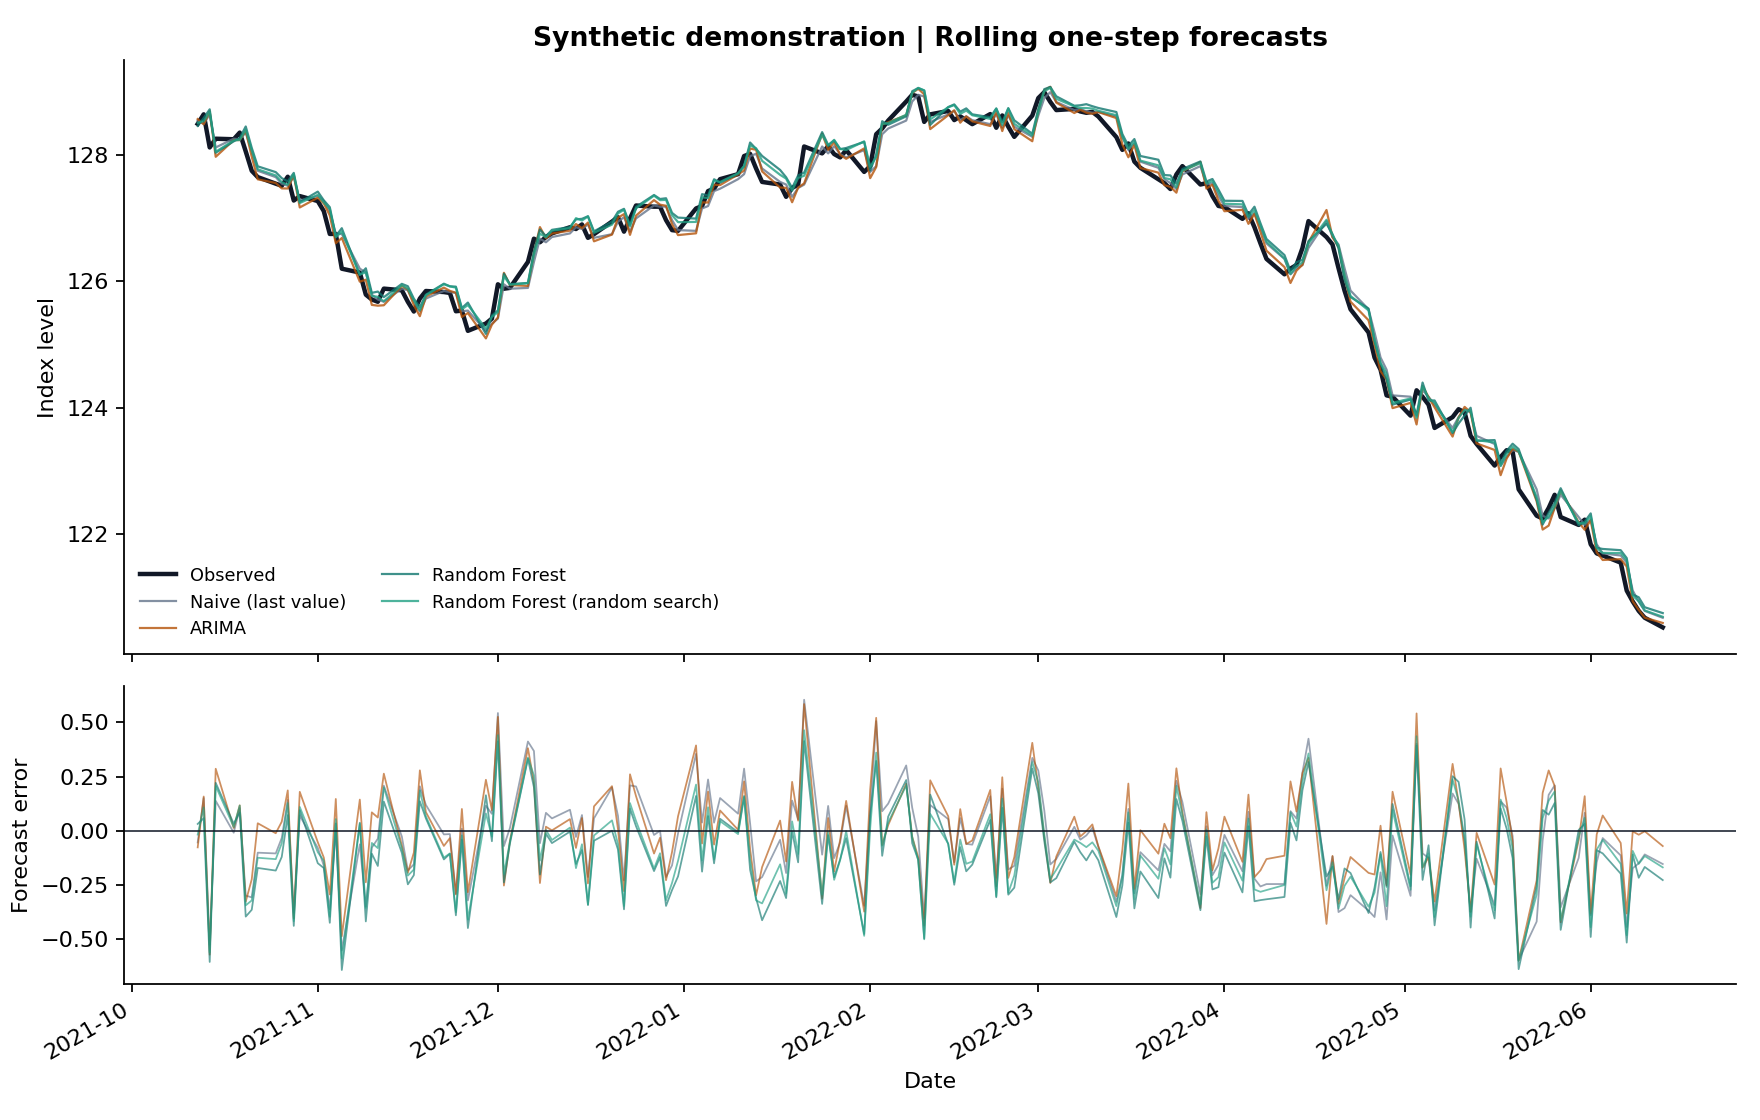

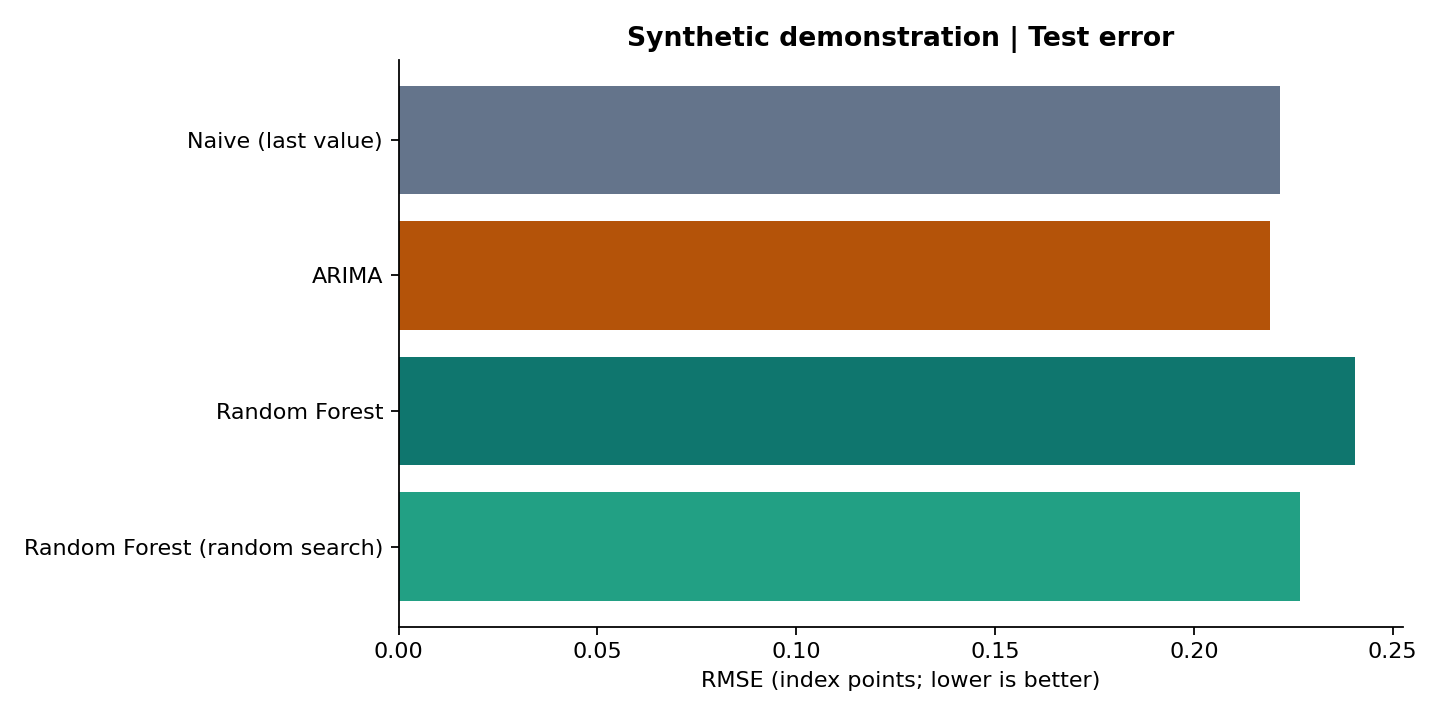

In [4]:
display(Image(filename=str(output / "figures" / "forecasts.png")))
display(Image(filename=str(output / "figures" / "model_comparison.png")))

## Inspect model drivers

Impurity importance describes the fitted Random Forest. It is not causal and can be affected by correlated features.

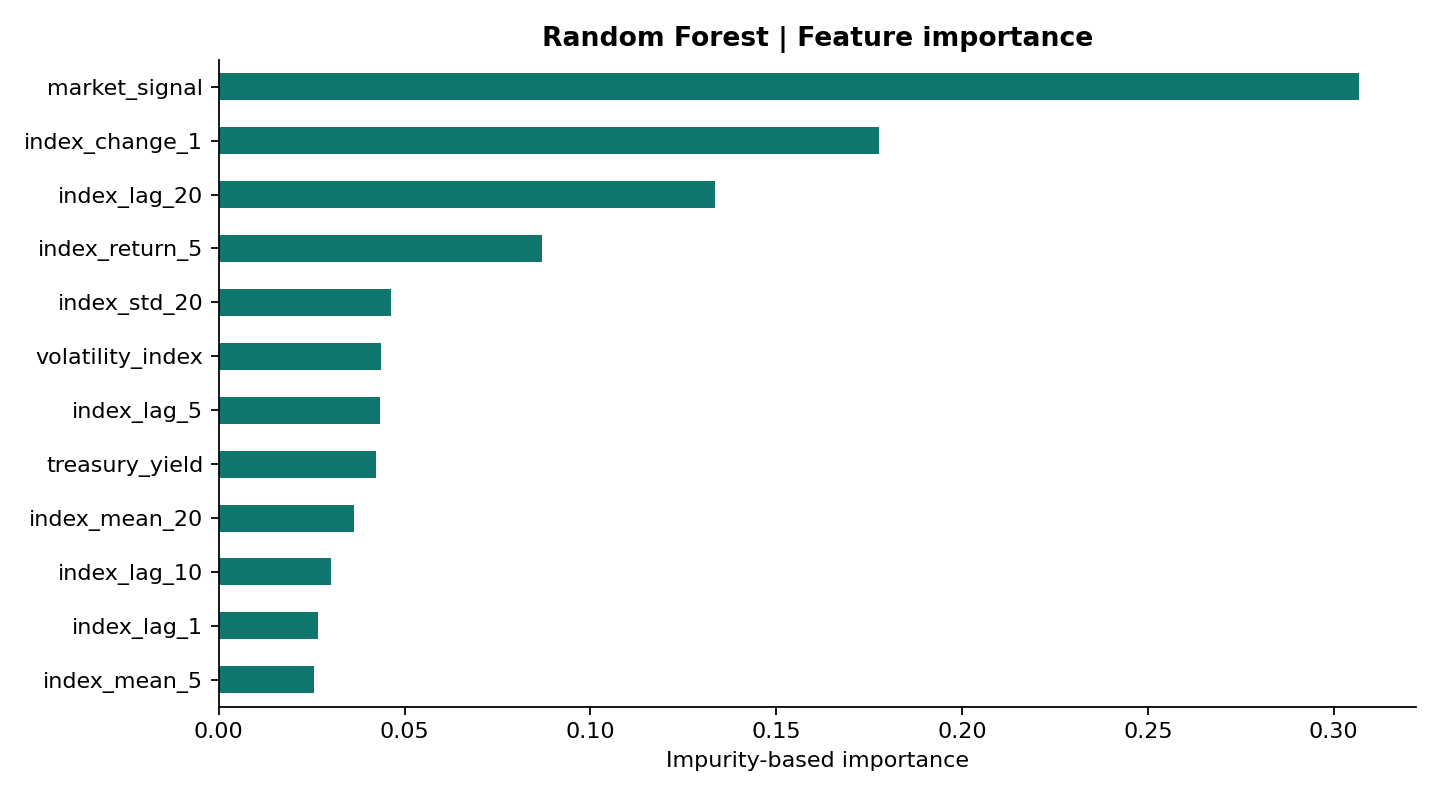

In [5]:
display(Image(filename=str(output / "figures" / "feature_importance.png")))

## Next steps

Use `greenbond legacy --data-dir Data` for the original local Excel exports or `greenbond run --input data/processed/combined.csv` for a standard CSV. Keep vendor data and credentials out of the public repository. See `docs/methodology.md` for release timing, macro revisions, and evaluation limitations.